# **Actividad N° 1 GPU**

Este ejercicio se ha optado para aplicar 2 multidimensiones en GPU. El ejemplo modifica el color de una imagen parametrizada a escala de grises. El cálculo de la escala se realiza convirtiendo los 3 canales RGB, que representan a los colores R (*rojo*)-G(*verde*)-B(*azul*), de cada pixel siguiendo la ecuación:

<center>$ Pixel=R*0.30+G*0.59+B*0.11$</center>

El objetivo es enseñar el funcionamiento del Lenguaje Python, CUDA y el manejo de imágenes a bajo nivel. El ejemplo es ilustrativo, ya que internamente el módulo Pillow posee varios filtros integrados.


---
### **1.  Preguntas de la Actividad**

a) Analice el siguiente ejemplo, visto en clase, y mencione en que lugar se realizan las siguientes partes.

*   Reservar memoria en GPU
*   Transferir datos de la CPU a la GPU
*   Transferir el Kernel y ejecutar el algoritmo
*   Transferir datos de la CPU a la GPU
*   Limpiar Memoria

b)¿ Cuál es la configuración inicial(por defecto) de Grilla y Bloques con que se ejecuta el algoritmo?

c) ¿Cuantos hilos se crean en total cuando se llama al kernel?

**Tips**: utilice la formula dim_hilo_x*dim_bloque_x*dim_hilo_y*dim_bloque_y para calcular la cantidad de threads total

d) ¿Cúantos hilos se planifican de más?

**Tips:** Los que no tengan condición verdadera en la condición dentro del kernel.

e) Utilice NVProf para medir la velocidad de respuesta que tiene el algoritmo durante su ejecución de acuerdo a la siguiente configuración y describa que sucede con los tiempos.

<div align="center">

| Configuración de Bloque  | Tiempo de ejecución del kernel |
| ------------- | ------------- |
| (16,19,1)     |               |
| (32,32,1)     |               |
| (32,33,1)     |               |
| (1024,1,1)    |               |

</div>

**Tips:**  Tener en cuenta el tamaño maximo de la configuración soportado por la GPU. Para saber su valor se debe ejecutar el siguiente comando:








In [1]:
!rm -rf cuda-samples
!git clone https://github.com/NVIDIA/cuda-samples.git

%cd cuda-samples
!git checkout v13.1

%cd Samples/1_Utilities/deviceQuery
!nvcc deviceQuery.cpp -I ../../../Common -o deviceQuery

!echo "------------------------------------------------------------------- "
!./deviceQuery

Cloning into 'cuda-samples'...
remote: Enumerating objects: 31872, done.
remote: Counting objects: 100% (7276/7276), done.
remote: Compressing objects: 100% (416/416), done.
remote: Total 31872 (delta 6896), reused 6985 (delta 6859), pack-reused 24596 (from 2)
Receiving objects: 100% (31872/31872), 137.46 MiB | 20.48 MiB/s, done.
Resolving deltas: 100% (27614/27614), done.
Updating files: 100% (2022/2022), done.
/content/cuda-samples
Updating files: 100% (3911/3911), done.
Note: switching to 'v13.1'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.

---
# 2 Armado del ambiente
Toma la dirección web de una imagen con acceso público en internet, la deja disponible al contexto de ejecución del cuaderno Colab.

In [7]:

#@title # 2.1 Parámetros de ejecución
#@markdown ---
#@markdown ### Especifique la URL de la imagen:
url_imagen = "https://raw.githubusercontent.com/soa-pc-unlam/ProgramacionConcurrente/refs/heads/main/Enunciados%20TPs/TP-GPU/Imagenes/MK-Maxi-Esteban.jpeg" #@param {type:"string"}

#@markdown ---
# Leo la imagen desde internet.
#!wget https://github.com/wvaliente/SOA_HPC/blob/main/unlam.jpg?raw=true -O imagen.jpg

# TODO: Mejorar informaciòn y resutlado de ejecución.
!wget {url_imagen} -O imagen.jpg

--2026-06-03 18:58:20--  https://raw.githubusercontent.com/soa-pc-unlam/ProgramacionConcurrente/refs/heads/main/Enunciados%20TPs/TP-GPU/Imagenes/MK-Maxi-Esteban.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 158004 (154K) [image/jpeg]
Saving to: ‘imagen.jpg’

imagen.jpg          100%[===================>] 154.30K  --.-KB/s    in 0.01s   

2026-06-03 18:58:20 (12.2 MB/s) - ‘imagen.jpg’ saved [158004/158004]



---
## 2.2 Instala en el cuaderno el módulo CUDA de Python.

In [3]:
!pip install pycuda

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 32.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 7.4 MB/s eta 0:00:00
  Created wheel for pycuda: filename=pycuda-2026.1-cp312-cp312-linux_x86_64.whl size=659447 sha256=e6a8a84305d9869363d59de344b817bb12c4d1ac68e7390e11335757213fc689
  Stored in directory: /root/.cache/pip/wheels/90/2a/71/75ec0cc316cc0ff494bfffa2935e02580129cb7f859a0cfd8f
Successfully built pycuda


---
# 3 Desarrollo
Ejecución del algoritmo escala de grises en GPU.

Imagen del filtro:  imagen.jpg  - tipo  RGB - [ 800 ,  600 ]
Imagen del filtro:  imagen.jpg  - tipo  RGB - [ 800 ,  600 ]
Grilla : [ 134 , 100 ], Bloques: [ 6 , 6  ] 


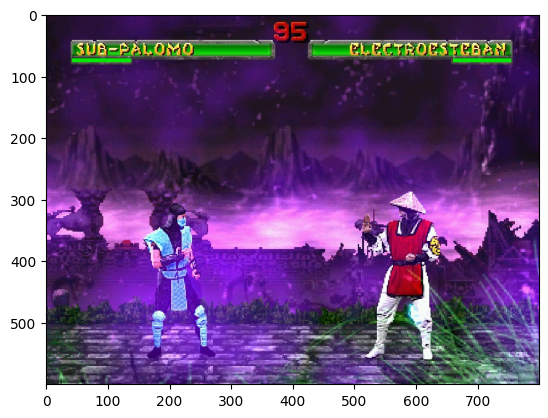

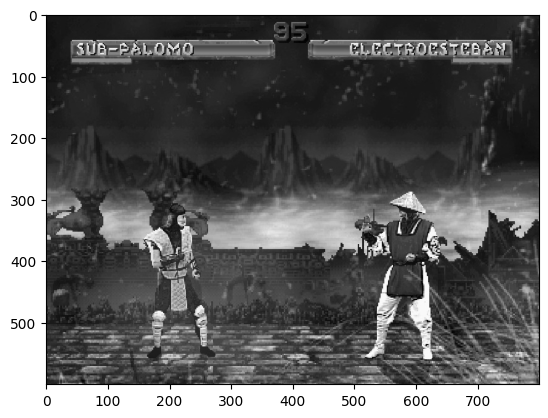

In [14]:
#Comentar esta linea para mostrar las imagenes
#%%writefile filter_image.py

#Comentar esta linea para medir los tiempos
%matplotlib inline

import matplotlib.pyplot as plt
import numpy
from PIL import Image
import pycuda.driver as cuda
import pycuda.autoinit
from pycuda.compiler import SourceModule

# -----------------------------------------------------------------------------
img_nombre = 'imagen.jpg'
image = Image.open( img_nombre )

# summarize some details about the image
img_ancho, img_alto  = image.size

# -----------------------------------------------------------------------------
img_O_cpu = numpy.asarray(image)
img_O_cpu = img_O_cpu.astype( numpy.int32() )
img_R_cpu = numpy.empty_like( img_O_cpu)

img_O_gpu = cuda.mem_alloc( img_O_cpu.nbytes )
img_R_gpu = cuda.mem_alloc( img_R_cpu.nbytes )

cuda.memcpy_htod( img_O_gpu, img_O_cpu )
cuda.memcpy_htod( img_R_gpu, img_R_cpu )

# -----------------------------------------------------------------------------

module = SourceModule("""

__global__ void kernel_img(int ancho, int alto, int *img_O, int *img_R)
{
  int idx = threadIdx.x + blockIdx.x * blockDim.x;
  int idy = threadIdx.y + blockIdx.y * blockDim.y;

  if (idx < ancho && idy < alto)
  {
    int pos_pixel = ((idy * ancho) + idx) * 3;

    float fGris = 0.0;
    fGris += img_O[pos_pixel]     * 0.30;
    fGris += img_O[pos_pixel + 1] * 0.59;
    fGris += img_O[pos_pixel + 2] * 0.11;

    int gris = (int)fGris;

    img_R[pos_pixel]     = gris;
    img_R[pos_pixel + 1] = gris;
    img_R[pos_pixel + 2] = gris;
  }
}
""")

# -----------------------------------------------------------------------------
kernel = module.get_function("kernel_img")

dim_hilo_x = 6
dim_bloque_x = int( (img_ancho+dim_hilo_x-1) / dim_hilo_x )

dim_hilo_y = 6
dim_bloque_y = int( (img_alto+dim_hilo_y-1) / dim_hilo_y )

# -----------------------------------------------------------------------------
kernel( numpy.int32(img_ancho), numpy.int32(img_alto), img_O_gpu, img_R_gpu,
        block=( dim_hilo_x, dim_hilo_y, 1 ),
        grid=(dim_bloque_x, dim_bloque_y,1) )



# -----------------------------------------------------------------------------
cuda.memcpy_dtoh( img_R_cpu, img_R_gpu )

img_O_gpu.free()
img_R_gpu.free()

# -----------------------------------------------------------------------------
# Muestro los atributos de la imagen y como se ve antes del seudo filtro.
print("Imagen del filtro: ", img_nombre , " - tipo " , image.mode , "- [" , img_ancho , ", " , img_alto , "]" )
# -----------------------------------------------------------------------------
# Muestro los atributos de la imagen y como se ve antes del seudo filtro.
print("Imagen del filtro: ", img_nombre , " - tipo " , image.mode , "- [" , img_ancho , ", " , img_alto , "]" )
print( "Grilla : [", dim_bloque_x, ",", dim_bloque_y, "], Bloques: [", dim_hilo_x, ",", dim_hilo_y, " ] "  )


# -----------------------------------------------------------------------------
# Muestro la imagen Original el filtro.
plt.figure()
imgplot=plt.imshow( img_O_cpu )

# Muestro la imagen luego de aplicarle el filtro.
plt.figure()
imgplot=plt.imshow( img_R_cpu )



## 3.1 Ejecución y profiling del script

Uitlizando nvprof se ejecuta el script y se miden los tiempos de ejecución.

In [5]:
!nvprof python filter_image.py

==10206== NVPROF is profiling process 10206, command: python3 filter_image.py
Imagen del filtro:  imagen.jpg  - tipo  RGB - [ 800 ,  600 ]
Imagen del filtro:  imagen.jpg  - tipo  RGB - [ 800 ,  600 ]
Grilla : [ 25 , 19 ], Bloques: [ 32 , 32  ] 
==10206== Profiling application: python3 filter_image.py
==10206== Profiling result:
            Type  Time(%)      Time     Calls       Avg       Min       Max  Name
 GPU activities:   87.73%  16.680ms         1  16.680ms  16.680ms  16.680ms  [CUDA memcpy DtoH]
                   11.47%  2.1799ms         2  1.0899ms  1.0447ms  1.1351ms  [CUDA memcpy HtoD]
                    0.80%  152.32us         1  152.32us  152.32us  152.32us  kernel_img
      API calls:   51.13%  201.85ms         1  201.85ms  201.85ms  201.85ms  cuCtxCreate
                   39.23%  154.88ms         1  154.88ms  154.88ms  154.88ms  cuCtxDetach
                    6.55%  25.849ms         1  25.849ms  25.849ms  25.849ms  cuMemcpyDtoH
                    1.32%  5.2283ms     

---
# 6 Bibliografía

[1]Algoritmo de inversion de colores [Algoritmo](https://www.youtube.com/watch?v=w4GZPcIrvGs)

[2] Documentacion Pycuda [WEB](https://documen.tician.de/pycuda/index.html)

[3] Repositorio Pycuda [WEB](https://pypi.org/project/pycuda/)
